In [15]:
import cv2
import matplotlib.pyplot as plt
from src.preprocessing.preprocess import Preprocessing
import json 

import pytesseract
tesseract_path = r'C:\Program Files\Tesseract-OCR\tesseract.exe'
pytesseract.pytesseract.tesseract_cmd = tesseract_path

In [16]:
# load config:
try:
    with open("config.json", "r", encoding="utf-8") as file:
        loaded_config = json.load(file)
        print("Config successfully loaded!")
except FileNotFoundError:
    print("Error: config.json not found. Falling back to default settings.")
    loaded_config = {}
except json.JSONDecodeError:
    print("Error: Invalid JSON format in config.json. Please check your syntax.")
    loaded_config = {}

Config successfully loaded!


In [17]:
pipeline = Preprocessing(config=loaded_config)
    
image_path = "data/input/preprocess/31.png"


--- Pipeline Results ---
Metadata: {'status': 'success', 'is_blank': False, 'confidence': 0.9808031241477567, 'comment': 'rf_model (score=0.0192)', 'qr_codes': []}


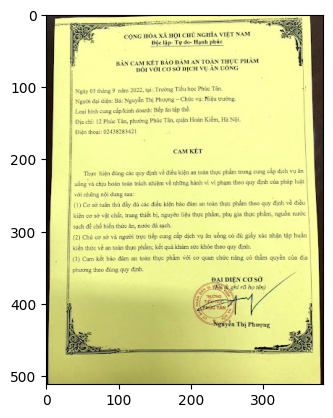

In [18]:
test_image = cv2.imread(image_path)

if test_image is None:
    print(f"Error: Could not load image from {image_path}")
else:
    # processed_image, meta_data = pipeline._process(test_image)
    result = pipeline._process(test_image)
    processed_image = result.image
    meta_data = result.metadata
    print("\n--- Pipeline Results ---")
    print(f"Metadata: {meta_data}")
    
plt.imshow(cv2.cvtColor(processed_image, cv2.COLOR_BGR2RGB))
plt.show()

In [19]:
print(result)

IMAGE
  size     : 384 x 512
  channels : 3
  dtype    : uint8

METADATA
  status     : success
  is_blank   : False
  confidence : 0.9808
  qr_count   : 0


In [ ]:
import os
import json
import cv2
import pytesseract
from src.preprocessing.preprocess import Preprocessing
from ocr.tesseract import TesseractParams, TesseractModel, TesseractOCR

class DocumentPipeline:
    def __init__(self, config_path, tesseract_cmd):
        pytesseract.pytesseract.tesseract_cmd = tesseract_cmd
        self.config = self._load_config(config_path)
        self.preprocessor = Preprocessing(config=self.config)
        self.ocr_engine = TesseractOCR(
            model=TesseractModel()
        )

    def _load_config(self, path):
        try:
            with open(path, "r", encoding="utf-8") as f:
                return json.load(f)
        except Exception:
            return {}

    def process_single_file(self, file_path, output_dir):
        """Processes a single image file for testing purposes."""
        if not os.path.exists(file_path):
            print(f"Error: File {file_path} not found.")
            return None

        img = cv2.imread(file_path)
        if img is None:
            print(f"Error: Could not decode image {file_path}.")
            return None

        # Preprocessing
        prep_res = self.preprocessor._process(img)
        
        # Tạo thư mục output nếu chưa có
        os.makedirs(output_dir, exist_ok=True)
        
        # Save preprocessed image (Ảnh gốc sau khi tiền xử lý, chưa có box)
        base_save_path = os.path.join(output_dir, "test_output_" + os.path.basename(file_path))
        cv2.imwrite(base_save_path, prep_res.image)

        # OCR Inference
        rgb_img = cv2.cvtColor(prep_res.image, cv2.COLOR_BGR2RGB)
        ocr_results = self.ocr_engine.recognize([rgb_img])
        
        ocr_res = ocr_results[0]
        
        serialized_blocks = []
        full_text_array = []
        
        # --- BẮT ĐẦU PHẦN VẼ BOX ---
        # Tạo một bản sao của ảnh để vẽ lên, tránh làm hỏng ảnh gốc
        vis_image = prep_res.image.copy()
        # -----------------------------

        if isinstance(ocr_res.texts, str):
            serialized_blocks = ocr_res.texts
            full_text_array.append(ocr_res.texts)
        else:
            for block in ocr_res.texts:
                full_text_array.append(block.text)
                
                # Lấy tọa độ x, y, w, h
                x, y, w, h = block.bounding_box()
                conf = block.confidence
                
                serialized_blocks.append({
                    "text": block.text,
                    "confidence": round(conf, 4),
                    "bounding_box": (x, y, w, h),
                    "polygon": block.bounding_polygon
                })
                
                # Vẽ khung chữ nhật (Màu xanh lá cây: BGR = 0, 255, 0, độ dày nét = 2)
                cv2.rectangle(vis_image, (x, y), (x + w, y + h), (0, 255, 0), 2)
                
                # Bổ sung: Vẽ text in điểm Confidence nhỏ ở góc trên Box (Màu đỏ)
                # Lưu ý: cv2.putText không hỗ trợ tốt tiếng Việt có dấu, nên ta chỉ in số
                text_label = f"{conf:.2f}"
                cv2.putText(vis_image, text_label, (x, max(y - 5, 10)), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 0, 255), 1)

        # Lưu bức ảnh đã được vẽ Box
        vis_save_path = os.path.join(output_dir, "visualized_" + os.path.basename(file_path))
        cv2.imwrite(vis_save_path, vis_image)

        result = {
            "file": os.path.basename(file_path),
            "output_path": base_save_path,
            "visualized_path": vis_save_path, # Thêm đường dẫn ảnh đã vẽ box vào log
            "metadata": prep_res.metadata,
            "full_text": " ".join(full_text_array), 
            "blocks": serialized_blocks,          
            "average_confidence": round(ocr_res.confidence, 4) if not isinstance(ocr_res.texts, str) else 0.0
        }
        
        return result

if __name__ == "__main__":
    pipeline = DocumentPipeline(
        config_path="config.json",
        tesseract_cmd=r'C:\Program Files\Tesseract-OCR\tesseract.exe'
    )

    test_file = "data/input/preprocess/1.png" 
    test_output_dir = "data/output/test"
    
    output_data = pipeline.process_single_file(
        file_path=test_file,
        output_dir=test_output_dir
    )
    
    if output_data:
        print(json.dumps(output_data, indent=2, ensure_ascii=False))

{
  "file": "1.png",
  "output_path": "data/output/test\\test_output_1.png",
  "metadata": {
    "status": "success",
    "is_blank": false,
    "confidence": 0.9456258857366263,
    "comment": "rf_model (score=0.0544)",
    "qr_codes": []
  },
  "full_text": "TÒA ÁN NHÂN DÂN CỘNG HÒA XÃ HỘI CHỦ NGHĨA VIỆT NAM TỈNH BN Độc lập - Tự do - Hạnh phúc Bản án số: 03/2022/DSST Ngày: 23/11/2022 V⁄»: Tranh chấp về kiện đòi tài sản l -_ NHÂN DANH NƯỚC CỘNG HÒA XÃ HỘI CHỦ NGHĨA VIỆT NAM TÒA ÁN NHÂN DÂN TỈNH BN - Thành phần Hội đồng xét xử sơ thẩm gồm có: Thẩm phán - Chủ tọa phiên tòa: Bà Nguyễn T5Mai. Các Hội thẩm nhân dân: Ông Trần Minh Phương Ông Nguyễn Văn Kỹ - Thư ký phiên tòa: Bà Lưu Thị TSNhung - Thư ký Tòa án nhân dân tỉnh BN. - Đại diện Viện kiểm sát nhân dân tỉnh BN tham gia phiên tòa: Bà Thân Thanh Huyền - Kiểm sát viên. Ngày 23 tháng II năm 2022, tại Trụ sở Toà án nhân dân tỉnh BN xét xử sơ thâm công khai vụ án thụ lý sô: 09/2020/TLST-DS ngày 03 tháng 02 năm 2020 về ““Tranh chấp kiện đò

In [1]:
import os
import json
import cv2

from ocr.paddle import *
from src.preprocessing.preprocess import Preprocessing

class DocumentPipeline:
    def __init__(self, config_path: str):
        self.config = self._load_config(config_path)
        self.preprocessor = Preprocessing(config=self.config)
        self.ocr_engine = Paddle(
            model=PaddleModel(
                params=PaddleParams(
                    lang='en',
                    use_textline_orientation=True,   # was: use_angle_cls
                    device='cpu',                    # was: use_gpu=False
                )
            )
        )

    def _load_config(self, path: str) -> dict:
        try:
            with open(path, "r", encoding="utf-8") as f:
                return json.load(f)
        except Exception:
            return {}

    def process_single_file(self, file_path: str, output_dir: str) -> dict | None:
        """Processes a single image file for testing purposes."""
        if not os.path.exists(file_path):
            print(f"Error: File {file_path} not found.")
            return None

        img = cv2.imread(file_path)
        if img is None:
            print(f"Error: Could not decode image {file_path}.")
            return None

        # Preprocessing
        prep_res = self.preprocessor._process(img)

        # Save preprocessed image for visual verification
        os.makedirs(output_dir, exist_ok=True)
        save_path = os.path.join(output_dir, "test_output_" + os.path.basename(file_path))
        cv2.imwrite(save_path, prep_res.image)

        # OCR Inference — Paddle handles BGR→RGB internally via _to_rgb()
        ocr_results = self.ocr_engine.recognize([prep_res.image])

        ocr_res = ocr_results[0]

        result = {
            "file": os.path.basename(file_path),
            "output_path": save_path,
            "metadata": prep_res.metadata,
            "text": ocr_res.text,
            "confidence": ocr_res.confidence,
        }

        return result


if __name__ == "__main__":
    pipeline = DocumentPipeline(config_path="config.json")

    # Single file test
    test_file = "data/input/preprocess/1.png"
    test_output_dir = "data/output/test"

    output_data = pipeline.process_single_file(
        file_path=test_file,
        output_dir=test_output_dir,
    )

    if output_data:
        print(json.dumps(output_data, indent=2, ensure_ascii=False))

Creating model: ('PP-LCNet_x1_0_textline_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\kunnic\.paddlex\official_models\PP-LCNet_x1_0_textline_ori`.
c:\Users\kunnic\Desktop\code\VNDigitizeComprehensiveSystem_Team03\.venv\Lib\site-packages\paddle\utils\cpp_extension\extension_utils.py:711: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Creating model: ('PP-OCRv5_server_det', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\kunnic\.paddlex\official_models\PP-OCRv5_server_det`.
Creating model: ('en_PP-OCRv5_mobile_rec', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\kunnic\.paddlex\

=== type: <class 'paddlex.inference.pipelines.ocr.result.OCRResult'>
=== dir: ['_deps_', '_get_input_fn', '_img_writer', '_json_writer', '_rand_fn', '_save_funcs', '_to_img', '_to_json', '_to_str', 'clear', 'copy', 'fromkeys', 'get', 'img', 'items', 'json', 'keys', 'pop', 'popitem', 'print', 'save_all', 'save_to_img', 'save_to_json', 'setdefault', 'str', 'update', 'values']
=== json: {'res': {'input_path': None, 'page_index': None, 'model_settings': {'use_doc_preprocessor': False, 'use_textline_orientation': True}, 'dt_polys': [[[346, 100], [693, 100], [693, 144], [346, 144]], [[846, 95], [1603, 95], [1603, 135], [846, 135]], [[437, 149], [602, 149], [602, 198], [437, 198]], [[961, 141], [1487, 141], [1487, 189], [961, 189]], [[294, 204], [744, 204], [744, 252], [294, 252]], [[361, 268], [676, 265], [676, 312], [361, 316]], [[243, 319], [798, 319], [798, 367], [243, 367]], [[805, 411], [1074, 414], [1074, 462], [805, 459]], [[428, 459], [1455, 461], [1455, 511], [428, 509]], [[643, 547